In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Activation, Conv2D,
    MaxPooling2D, Flatten, Dropout, BatchNormalization,
    GlobalMaxPool2D, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50, MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
 

In [32]:
IMG_SIZE   = (80, 80)
Batch_size = 32
Epochs     = 20
Num_classes = 36 

In [33]:
DATA_ROOT  = "../data"  
TRAIN_DIR  = os.path.join(DATA_ROOT, "train")
TEST_DIR   = os.path.join(DATA_ROOT, "test")
VALID_DIR  = os.path.join(DATA_ROOT, "validation")
 
tf.random.set_seed(42)
np.random.seed(42)

# DATA EXPLORATION

In [ ]:
def build_dataset_df(root_dir, split_name):
    rows = []
    for class_name in sorted(os.listdir(root_dir)):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                rows.append({
                    'split':      split_name,
                    'class':      class_name,
                    'image_path': os.path.join(class_path, img_file)
                })
    return pd.DataFrame(rows)

df_train = build_dataset_df(TRAIN_DIR, 'train')
df_test  = build_dataset_df(TEST_DIR,  'test')
df_valid = build_dataset_df(VALID_DIR, 'validation')
df_all   = pd.concat([df_train, df_test, df_valid], ignore_index=True)

In [ ]:
df_all.head(10)

   split  class                        image_path
0  train  apple  ../data/train/apple/Image_28.jpg
1  train  apple  ../data/train/apple/Image_16.jpg
2  train  apple  ../data/train/apple/Image_17.jpg
3  train  apple  ../data/train/apple/Image_38.jpg
4  train  apple  ../data/train/apple/Image_10.jpg
5  train  apple  ../data/train/apple/Image_39.jpg
6  train  apple  ../data/train/apple/Image_76.png
7  train  apple  ../data/train/apple/Image_62.jpg
8  train  apple  ../data/train/apple/Image_63.jpg
9  train  apple  ../data/train/apple/Image_61.jpg


In [36]:
df_all.shape

(3825, 3)

In [37]:
df_all.isnull().sum()

split         0
class         0
image_path    0
dtype: int64

In [38]:
df_all['split'].value_counts()

split
train         3115
test           359
validation     351
Name: count, dtype: int64

In [39]:
df_all['class'].nunique()

36

In [40]:
sorted(df_all['class'].unique())

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

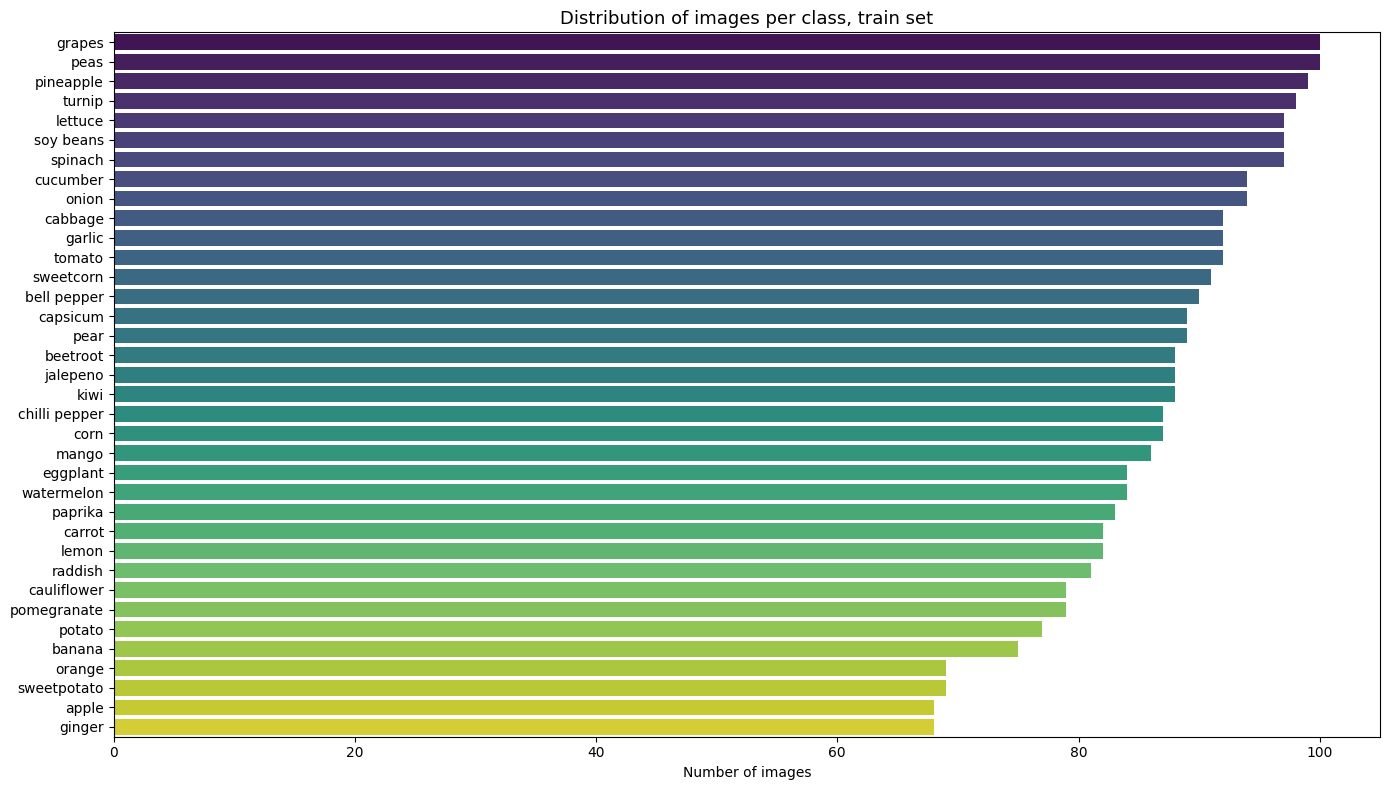

In [41]:
# distribution per class in train set
plt.figure(figsize=(14, 8))
order = df_train['class'].value_counts().index
sns.countplot(data=df_train, y='class', order=order, palette='viridis')
plt.title('Distribution of images per class, train set', fontsize=13)
plt.xlabel('Number of images')
plt.ylabel('')
plt.tight_layout()
plt.show()

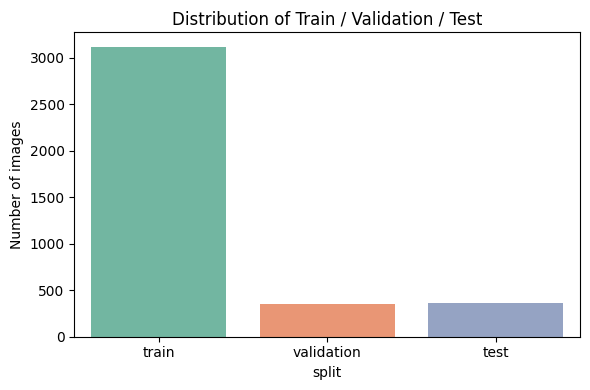

In [42]:
# distribution of splits
plt.figure(figsize=(6, 4))
sns.countplot(data=df_all, x='split',
              order=['train', 'validation', 'test'],
              palette='Set2')
plt.title('Distribution of Train / Validation / Test')
plt.ylabel('Number of images')
plt.tight_layout()
plt.show()

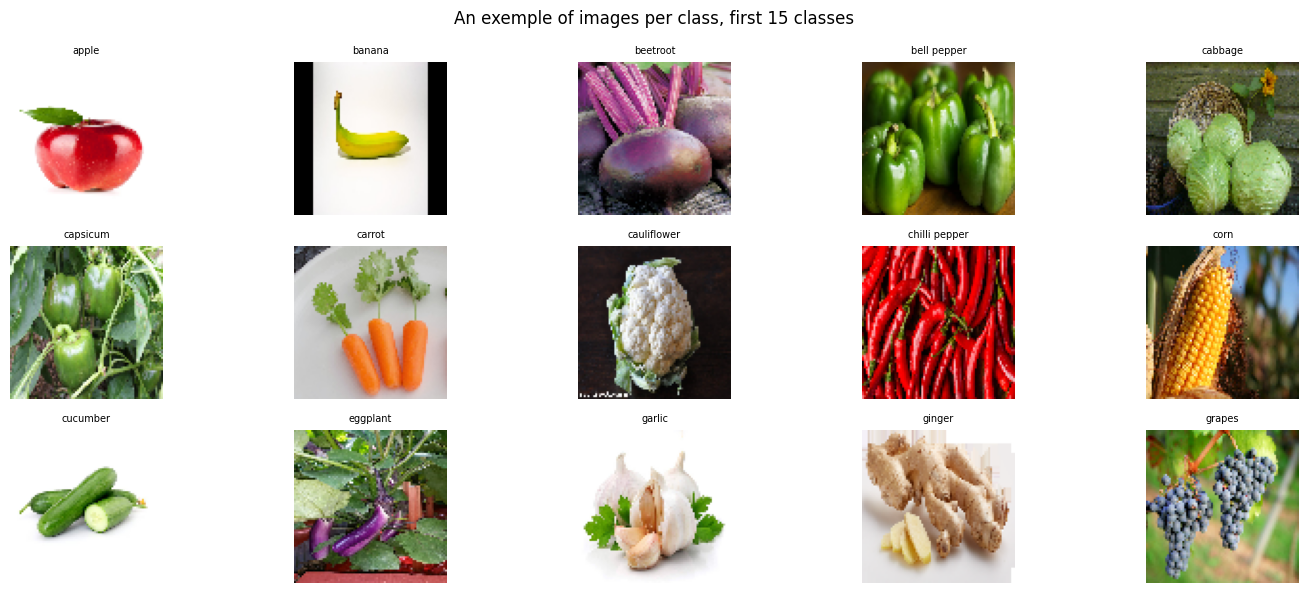

In [43]:
plt.figure(figsize=(15, 6))
sample = df_train.groupby('class').first().reset_index().head(15)
for i, (_, row) in enumerate(sample.iterrows(), 1):
    img = load_img(row['image_path'], target_size=(80, 80))
    plt.subplot(3, 5, i)
    plt.imshow(img)
    plt.title(row['class'], fontsize=7)
    plt.axis('off')
plt.suptitle('An exemple of images per class, first 15 classes')
plt.tight_layout()
plt.show()

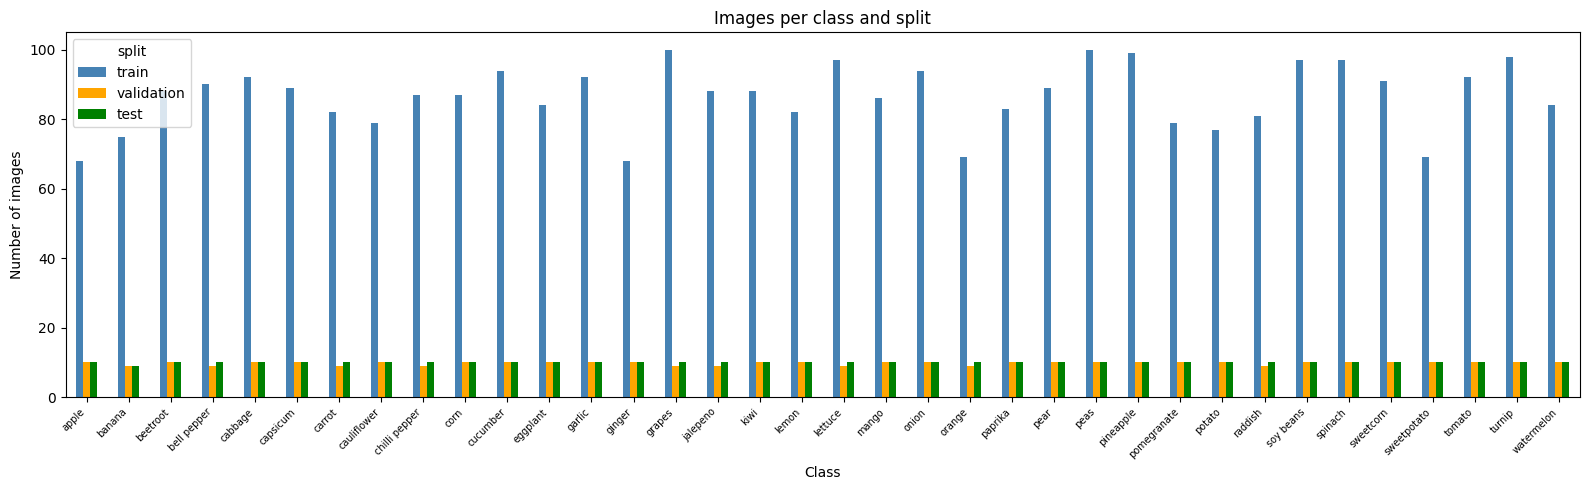

In [44]:
# distribution per class (comparison train vs validation vs test)
class_counts = df_all.groupby(['class', 'split']).size().unstack(fill_value=0)
class_counts[['train', 'validation', 'test']].plot(
    kind='bar', figsize=(16, 5), color=['steelblue', 'orange', 'green'])
plt.title('Images per class and split')
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

# DATA GENERATORS

In [45]:
#shuffle the images (shuffle=True on train)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
 
val_test_datagen = ImageDataGenerator(rescale=1./255)

#shuffle to prevent learning on one type at a time
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=Batch_size,
    class_mode='categorical',
    shuffle=True,      
    seed=42
)
 
val_gen = val_test_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=Batch_size,
    class_mode='categorical',
    shuffle=False
)
 
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=Batch_size,
    class_mode='categorical',
    shuffle=False
)
 
CLASS_NAMES  = list(train_gen.class_indices.keys())
Num_classes  = len(CLASS_NAMES)
print(f"\nNumăr clase detectate: {Num_classes}")
print("Clase:", CLASS_NAMES)
 

Found 3115 images belonging to 36 classes.
Found 351 images belonging to 36 classes.
Found 359 images belonging to 36 classes.

Număr clase detectate: 36
Clase: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


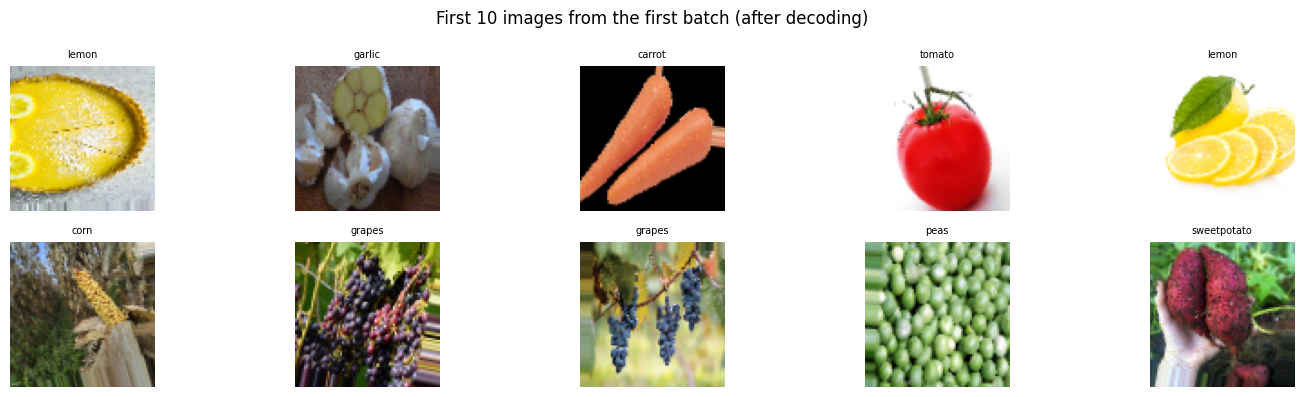

In [46]:
#decode amd display
plt.figure(figsize=(15, 4))
batch_x, batch_y = next(train_gen)
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(batch_x[i])
    plt.title(CLASS_NAMES[np.argmax(batch_y[i])], fontsize=7)
    plt.axis('off')
plt.suptitle('First 10 images from the first batch (after decoding)')
plt.tight_layout()
plt.show()

In [47]:
#CNN  model
model = Sequential()
 
#block 1
model.add(Conv2D(input_shape=(80, 80, 3), padding='same', filters=32, kernel_size=(7, 7)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))
 
#block 2
model.add(Conv2D(filters=64, padding='valid', kernel_size=(5, 5)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))
 
#block 3
model.add(Conv2D(filters=128, padding='valid', kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Dropout(0.2))
 
#block 4
model.add(Conv2D(filters=256, padding='valid', kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))
 
model.add(GlobalMaxPool2D())
model.add(Dense(units=256))
model.add(Activation('relu'))
model.add(Dropout(0.2))
 
#ginal layer, multiclass (softmax)
model.add(Dense(units=Num_classes))
model.add(Activation('softmax'))

In [48]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 80, 80, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 36, 36, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 36, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,093,092 (4.17 MB)

 Trainable params: 1,091,620 (4.16 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [49]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True)
]

print("\nModel Training")
history = model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)


Model Training
Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 95s 928ms/step - accuracy: 0.1493 - loss: 3.2888 - val_accuracy: 0.0285 - val_loss: 4.4004 - learning_rate: 0.0010
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 80s 813ms/step - accuracy: 0.2414 - loss: 2.5968 - val_accuracy: 0.0969 - val_loss: 4.7677 - learning_rate: 0.0010
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 79s 818ms/step - accuracy: 0.2838 - loss: 2.4053 - val_accuracy: 0.2137 - val_loss: 3.2244 - learning_rate: 0.0010
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 83s 852ms/step - accuracy: 0.3274 - loss: 2.2814 - val_accuracy: 0.2279 - val_loss: 3.0203 - learning_rate: 0.0010
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 88s 897ms/step - accuracy: 0.3518 - loss: 2.1751 - val_accuracy: 0.1823 - val_loss: 3.6273 - learning_rate: 0.0010
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 80s 818ms/step - accuracy: 0.3676 - loss: 2.1036 - val_accuracy: 0.3504 - val_loss: 2.2577 - learning_rate: 0.0010
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 86s 877ms/step - accuracy: 0

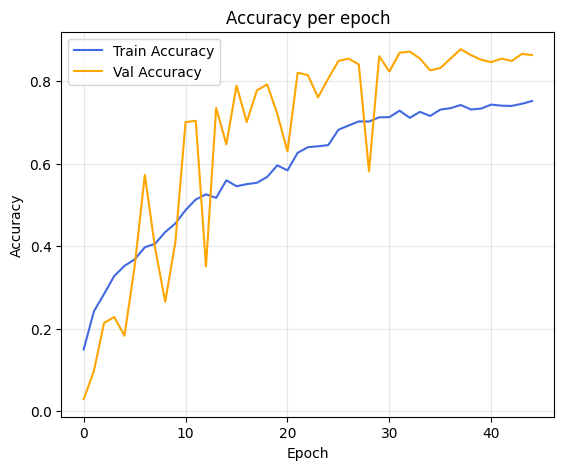

In [50]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy', color='royalblue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
plt.title('Accuracy per epoch')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True, alpha=0.3)


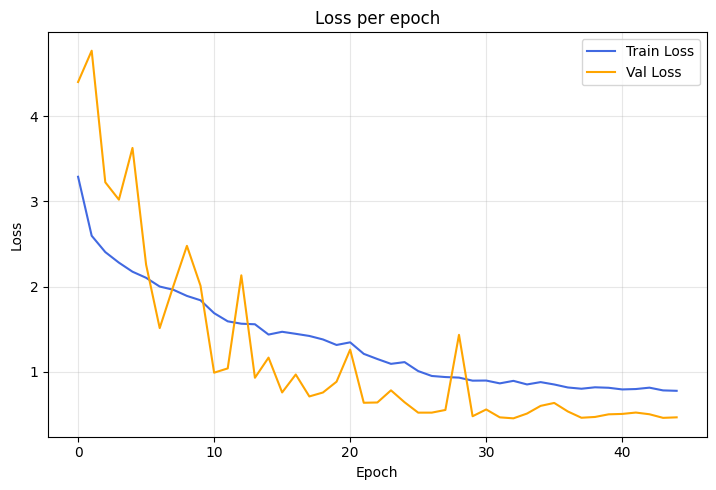

In [51]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss', color='royalblue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='orange')
plt.title('Loss per epoch')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

In [52]:
loss, accuracy = model.evaluate(test_gen, verbose=0)
print(f"\nTest Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")



Test Loss:     0.4609
Test Accuracy: 0.8802 (88.02%)



Classification report:
               precision    recall  f1-score   support

        apple       1.00      0.50      0.67        10
       banana       0.88      0.78      0.82         9
     beetroot       1.00      1.00      1.00        10
  bell pepper       0.80      0.80      0.80        10
      cabbage       1.00      0.90      0.95        10
     capsicum       0.88      0.70      0.78        10
       carrot       1.00      0.90      0.95        10
  cauliflower       1.00      1.00      1.00        10
chilli pepper       0.82      0.90      0.86        10
         corn       0.71      0.50      0.59        10
     cucumber       1.00      0.80      0.89        10
     eggplant       1.00      1.00      1.00        10
       garlic       1.00      1.00      1.00        10
       ginger       0.90      0.90      0.90        10
       grapes       1.00      1.00      1.00        10
     jalepeno       1.00      0.80      0.89        10
         kiwi       1.00      1.00      

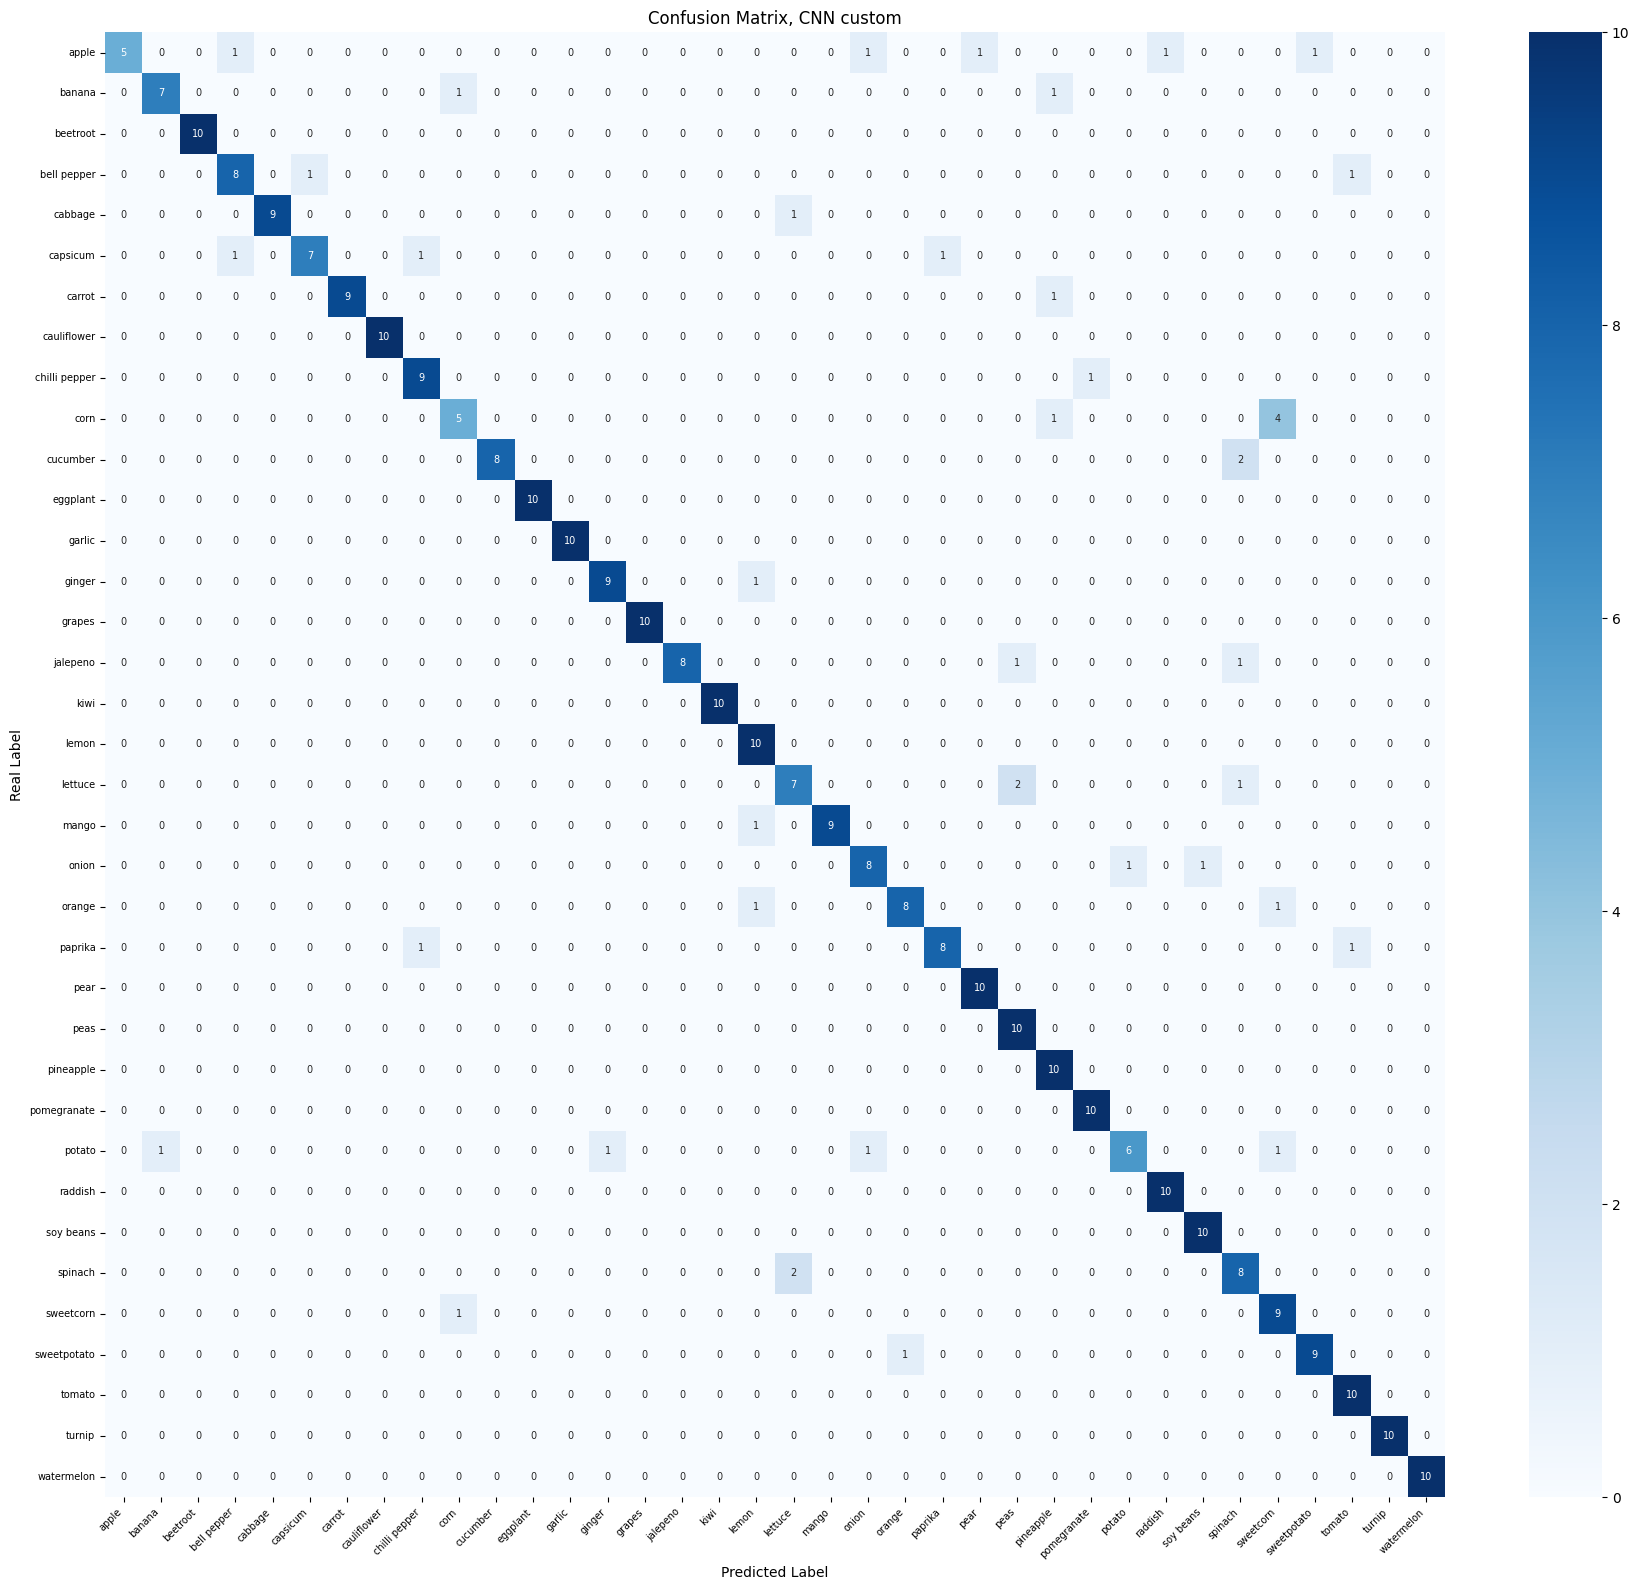

In [63]:
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes
 
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'size': 7})
plt.title('Confusion Matrix, CNN custom')
plt.ylabel('Real Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
def predict_imagine(img_path):
    img       = load_img(img_path, target_size=(80, 80))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    probs     = model.predict(img_array, verbose=0)[0]
    idx       = np.argmax(probs)
    clasa     = CLASS_NAMES[idx]
    incredere = probs[idx]

    #top 3 predictions
    top3_idx  = np.argsort(probs)[::-1][:3]

    plt.figure(figsize=(4, 4))
    plt.imshow(load_img(img_path, target_size=(80, 80)))
    plt.title(f"Clasă prezisă: {clasa}\nÎncredere: {incredere*100:.1f}%",
              fontsize=10, color='green')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Clasă prezisă : {clasa}")
    print(f"Încredere     : {incredere*100:.1f}%")
    print(f"Top 3 predicții:")
    for i in top3_idx:
        print(f"  {CLASS_NAMES[i]:20s}: {probs[i]*100:.1f}%")

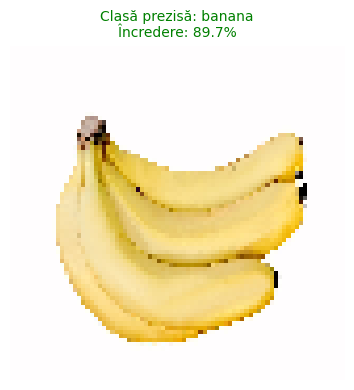

Clasă prezisă : banana
Încredere     : 89.7%
Top 3 predicții:
  banana              : 89.7%
  lemon               : 8.6%
  ginger              : 1.2%


In [56]:
predict_imagine("../data/test/banana/Image_1.jpg")

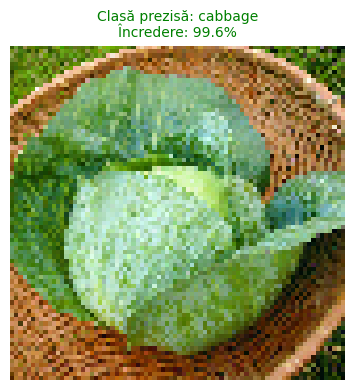

Clasă prezisă : cabbage
Încredere     : 99.6%
Top 3 predicții:
  cabbage             : 99.6%
  watermelon          : 0.3%
  cucumber            : 0.0%


In [57]:
predict_imagine("../data/test/cabbage/Image_1.jpg")

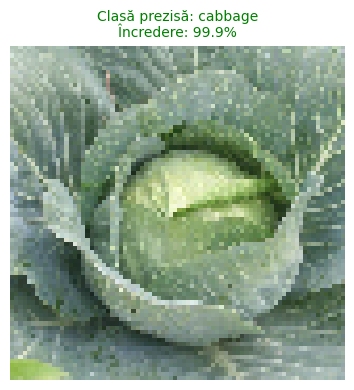

Clasă prezisă : cabbage
Încredere     : 99.9%
Top 3 predicții:
  cabbage             : 99.9%
  cucumber            : 0.0%
  watermelon          : 0.0%


In [58]:
predict_imagine("../data/test/cabbage/Image_3.jpg")

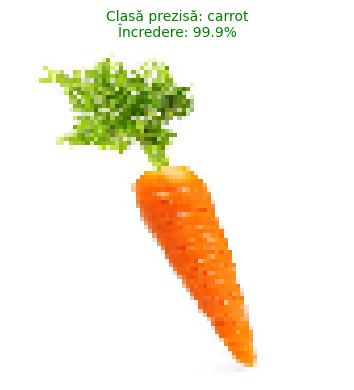

Clasă prezisă : carrot
Încredere     : 99.9%
Top 3 predicții:
  carrot              : 99.9%
  orange              : 0.1%
  pineapple           : 0.0%


In [59]:
predict_imagine("../data/carrot_test.jpg")

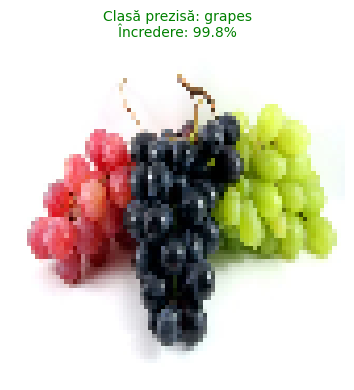

Clasă prezisă : grapes
Încredere     : 99.8%
Top 3 predicții:
  grapes              : 99.8%
  lettuce             : 0.1%
  pineapple           : 0.0%


In [62]:
predict_imagine("../data/grapes2_test.webp")

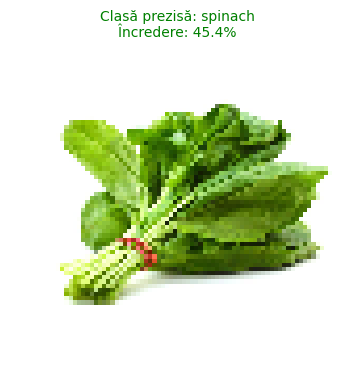

Clasă prezisă : spinach
Încredere     : 45.4%
Top 3 predicții:
  spinach             : 45.4%
  peas                : 28.5%
  lettuce             : 22.2%


In [65]:
predict_imagine("../data/spanac_test.jpg")